# Human Activity Recognition with a Hidden Markov Model

**Background and motivation.** Wearable inertial sensors are increasingly used in
low-resource health settings for remote monitoring of physical activity - tracking
rehabilitation and physiotherapy adherence, screening mobility in older adults, and
flagging inactivity in community-health programmes. In these settings a phone or wrist
device streams accelerometer and gyroscope signals continuously, but the *activity* a
person is performing (standing, walking, jumping, lying still) is never observed
directly; it is a hidden state that must be inferred from noisy measurements. This is
exactly the structure a Hidden Markov Model captures: hidden activity states emit
observable sensor features and evolve over time with realistic persistence. This project
collects real motion data for four activities, engineers time- and frequency-domain
features, and implements a Gaussian HMM **from scratch** (Viterbi + Baum-Welch) to decode
the activity sequence, validating the implementation against `hmmlearn` and evaluating on
unseen recordings.


In [1]:
import sys, pickle
sys.path.insert(0, 'src')
import numpy as np, pandas as pd
from pathlib import Path
from IPython.display import Image, display

import preprocess as pp, features as ft, hmm as hm, evaluate as ev

STATES   = pp.STATES
FS       = pp.TARGET_HZ
FEATURES = ft.FEATURE_NAMES
K, D     = len(STATES), len(FEATURES)
print('activities:', STATES, '| target rate:', FS, 'Hz | features:', D)

activities: ['standing', 'walking', 'jumping', 'still'] | target rate: 50 Hz | features: 11


## 1. Data collection

Four activities (standing, walking, jumping, still) were recorded with the Sensor Logger
app, capturing calibrated linear acceleration, gravity and gyroscope (x/y/z each) with a
Unix-nanosecond timestamp. Data were collected at two device rates (~50 Hz and ~100 Hz)
to reproduce a multi-device scenario, giving 54 labelled clips of 5-10 s and >=90 s per
activity, plus two continuous "mixed" sessions (all four activities in sequence) held out
for testing. The table below summarises the collected training set.

In [2]:
rows = []
for f in sorted(Path('data/raw').glob('*.csv')):
    df = pd.read_csv(f)
    rows.append((df['activity'].iloc[0], int(df['fs_hz'].iloc[0]),
                 float(df['seconds_elapsed'].iloc[-1])))
summ = pd.DataFrame(rows, columns=['activity', 'fs_hz', 'seconds'])
tbl = summ.groupby('activity').agg(files=('seconds', 'size'),
                                    total_seconds=('seconds', 'sum')).round(1)
tbl['rates_hz'] = summ.groupby('activity')['fs_hz'].apply(lambda s: sorted(s.unique()))
tbl

,files,total_seconds,rates_hz
activity,,,
jumping,13,99.7,"[50, 100]"
standing,13,105.3,"[50, 100]"
still,13,112.6,"[50, 100]"
walking,15,121.8,"[50, 100]"


## 2. Preprocessing and windowing

Each clip is (1) trimmed to <=10 s, (2) linearly interpolated onto a common **50 Hz**
grid so a window spans the same physical time regardless of source rate (sampling-rate
harmonisation), and (3) split into **2 s / 100-sample windows with 50% overlap**. The
window length is chosen from the sampling rate and the activity physics: walking and
jumping cycle at ~1-2 Hz, so a 2 s window captures 2-4 full cycles - long enough to
characterise the rhythm while staying locally stationary. The figure shows one
representative clip per activity; note that standing and still are both static in motion
but carry gravity on different axes, which is what makes them separable.

window: 100 samples = 2.0s @ 50Hz, hop 50 (50% overlap)
total training windows: 356
mixed_100hz_01.csv: 32 windows, 26 pure / 6 boundary
mixed_50hz_01.csv: 32 windows, 26 pure / 6 boundary


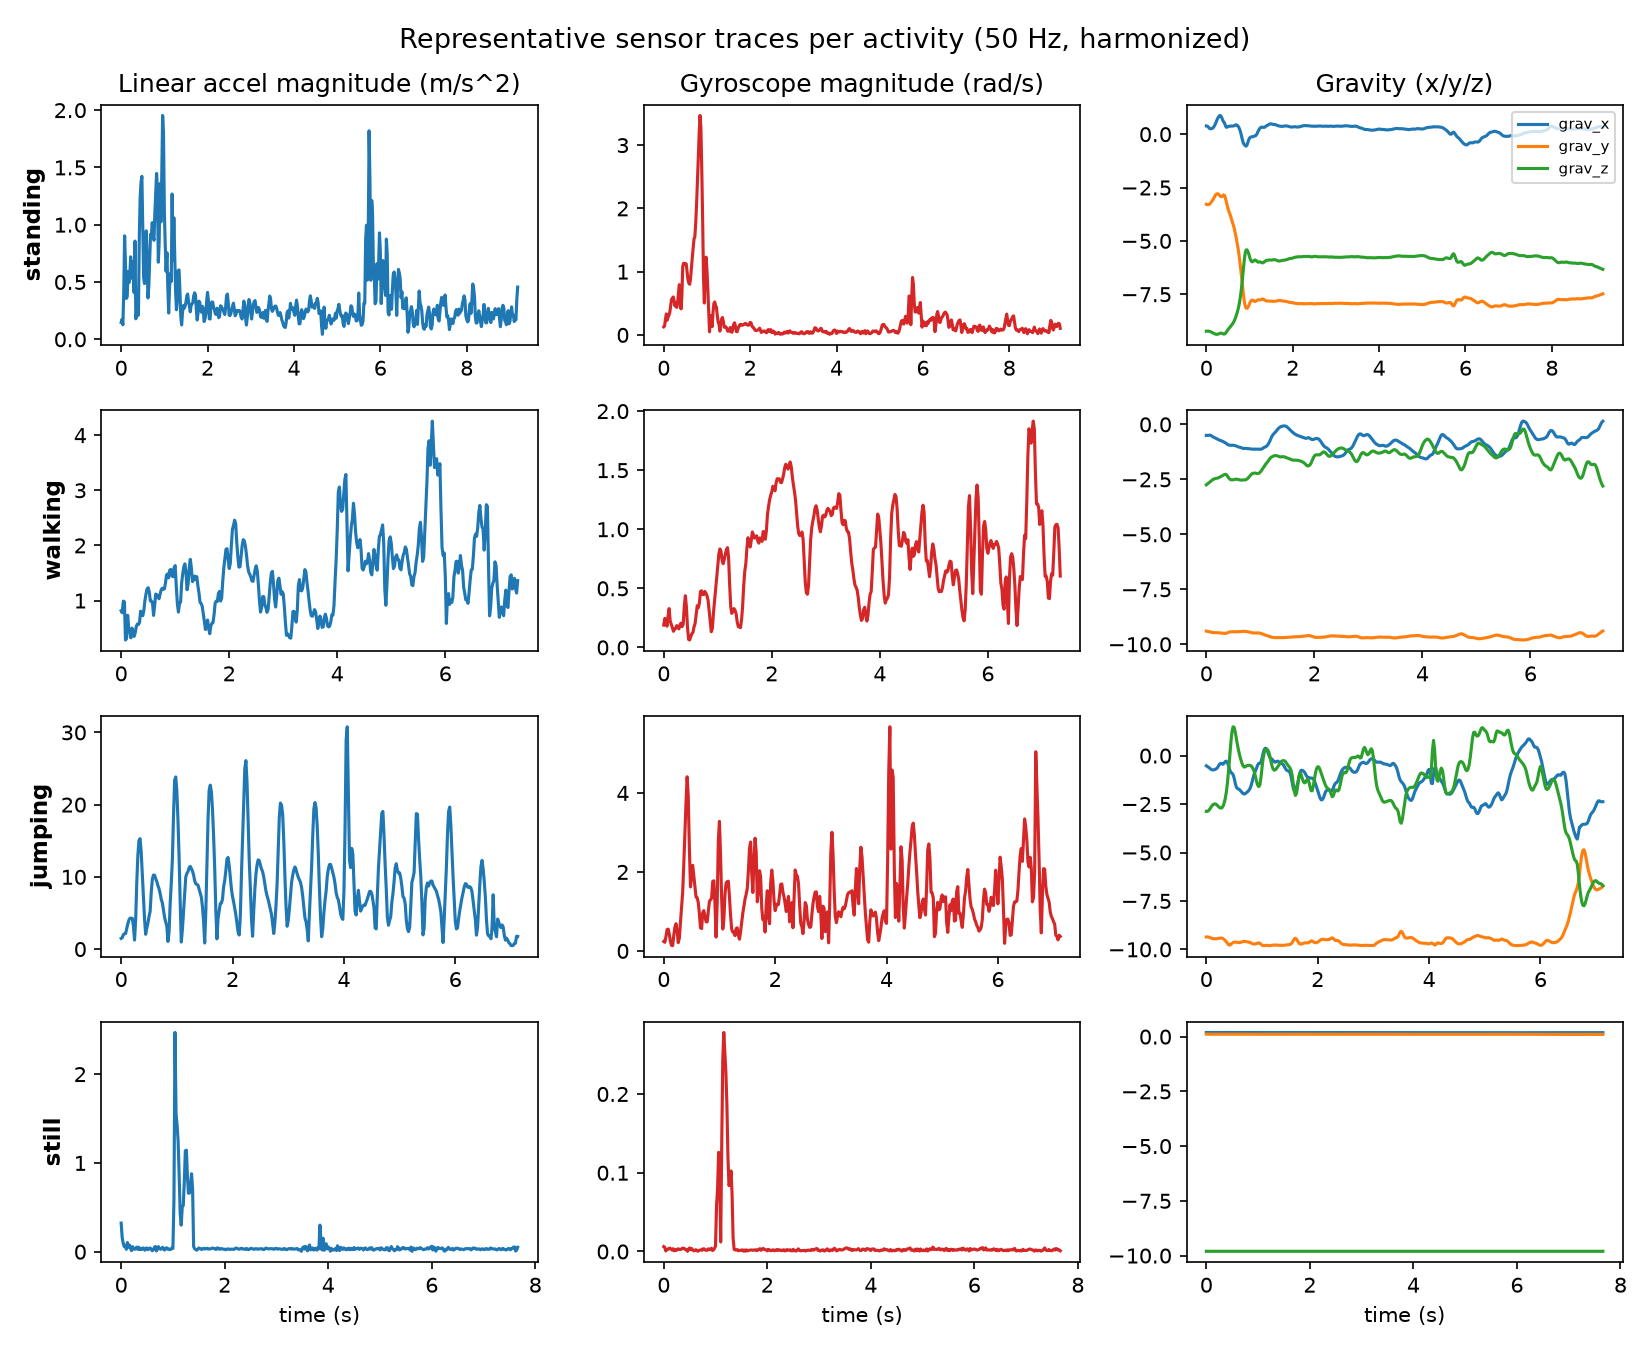

In [3]:
train_clips  = pp.process_train('data/raw')
test_sessions = pp.process_test('data/test', STATES)   # equal-segment labels; boundary windows flagged
print(f'window: {pp.WIN_LEN} samples = {pp.WIN_SECONDS}s @ {FS}Hz, hop {pp.HOP} (50% overlap)')
print('total training windows:', sum(len(c['X']) for c in train_clips))
for s in test_sessions:
    print(f"{s['name']}: {len(s['X'])} windows, {int(s['pure'].sum())} pure / {int((~s['pure']).sum())} boundary")

pp.plot_samples('data/raw', 'plots')
display(Image('plots/sample_signals.png'))

## 3. Feature extraction

Each window becomes an 11-dimensional feature vector: eight time-domain features
(`acc_rms`, `acc_var`, `acc_sma` for motion energy/intensity; `gyr_rms` for rotation;
`grav_x/y/z_mean` for device orientation; `corr_acc_xz` for coordinated motion) and three
FFT-derived frequency-domain features (`dom_freq`, `spec_energy`, `spec_entropy`). The
per-activity means below confirm separability: energy features separate dynamic from
static, gravity means separate standing from still, and dominant frequency separates
walking from jumping. Features are then Z-scored with statistics fit on **training windows
only** (applied to the test set) - necessary because diagonal-covariance Gaussian
emissions are ill-conditioned when features span orders of magnitude, and fitting on train
only prevents leakage.

In [4]:
train_F = ft.featurize(train_clips, FS)
test_F  = ft.featurize(test_sessions, FS)

separability = ft.separability_table(train_F, STATES)   # raw, pre-scaling
mean, std = ft.fit_scaler(train_F)
train_F = ft.apply_scaler(train_F, mean, std)
test_F  = ft.apply_scaler(test_F, mean, std)
separability

,standing,walking,jumping,still
acc_rms,0.521,2.480,12.468,0.042
acc_var,0.320,2.867,43.275,0.004
acc_sma,0.628,3.348,14.912,0.043
gyr_rms,0.311,1.204,2.396,0.004
grav_x_mean,-0.520,-0.156,-0.714,0.173
grav_y_mean,-9.196,-9.484,-9.183,0.108
grav_z_mean,-1.853,-1.476,-0.750,-9.805
corr_acc_xz,-0.042,0.031,-0.060,-0.036
dom_freq,4.271,1.237,2.833,11.973
spec_energy,1601.271,14335.610,216400.203,18.730


## 4. HMM setup and implementation

The model is a Gaussian HMM with four hidden states (the activities) and
diagonal-covariance Gaussian emissions, implemented from scratch in numpy and log-space.
Because each training clip contains a single activity, training clips are concatenated in
randomised order into "montages" so that clip boundaries supply genuine inter-activity
transitions. The model is **initialised supervised** (per-state Gaussians by MLE from
labelled windows, keeping state k aligned to activity k) and then **refined with
Baum-Welch** (EM) to convergence on a log-likelihood criterion. The core Viterbi and
Baum-Welch source is shown below; the full module is in `src/hmm.py`.

In [5]:
import inspect
print(inspect.getsource(hm.GaussianHMM.viterbi))
print(inspect.getsource(hm.GaussianHMM.fit_baum_welch))

    def viterbi(self, X):
        logB = self._log_emission(X)
        T = logB.shape[0]
        logpi, logA = np.log(self.pi + 1e-300), np.log(self.A + 1e-300)
        delta = np.empty((T, self.K))
        psi = np.zeros((T, self.K), dtype=int)
        delta[0] = logpi + logB[0]
        for t in range(1, T):
            scores = delta[t - 1][:, None] + logA        # (K_prev, K_cur)
            psi[t] = np.argmax(scores, axis=0)
            delta[t] = logB[t] + np.max(scores, axis=0)
        path = np.empty(T, dtype=int)
        path[-1] = int(np.argmax(delta[-1]))
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path

    def fit_baum_welch(self, sequences, max_iter=100, tol=1e-4, verbose=True):
        history = []
        for it in range(max_iter):
            # accumulators
            pi_acc = np.zeros(self.K)
            A_num = np.zeros((self.K, self.K))
            A_den = np.zeros(self.K)
            m_num = np.zeros((self.K, 

In [6]:
seqs, labs = hm.build_montages(train_F, n_montages=5, seed=0)

model = hm.GaussianHMM(K, D)
model.fit_supervised(seqs, labs)
init_pred = np.concatenate([model.viterbi(s) for s in seqs])
init_true = np.concatenate(labs)
print('supervised-init training accuracy:', round(float(np.mean(init_pred == init_true)), 3))

print('\nBaum-Welch refinement:')
history = model.fit_baum_welch(seqs, max_iter=100, tol=1e-4, verbose=True)

supervised-init training accuracy: 0.961

Baum-Welch refinement:
  BW iter  0  logL = 209.596
  BW iter  1  logL = 1021.549
  BW iter  2  logL = 1321.601
  BW iter  3  logL = 1361.422
  BW iter  4  logL = 1374.363
  BW iter  5  logL = 1376.648
  BW iter  6  logL = 1378.892
  BW iter  7  logL = 1386.665
  BW iter  8  logL = 1388.567
  BW iter  9  logL = 1388.571
  BW iter 10  logL = 1388.571
  converged at iter 10 (|dLL| < 0.0001)


### Convergence, transition matrix, and validation against `hmmlearn`

Baum-Welch increases the log-likelihood monotonically and stops on the `|dLL| < 1e-4`
criterion. The transition matrix is strongly diagonal, reflecting realistic activity
persistence across 1 s hops. Finally, the from-scratch forward log-likelihood and Viterbi
path are cross-checked against `hmmlearn` with identical parameters - they match to machine
precision, confirming the implementation is correct.

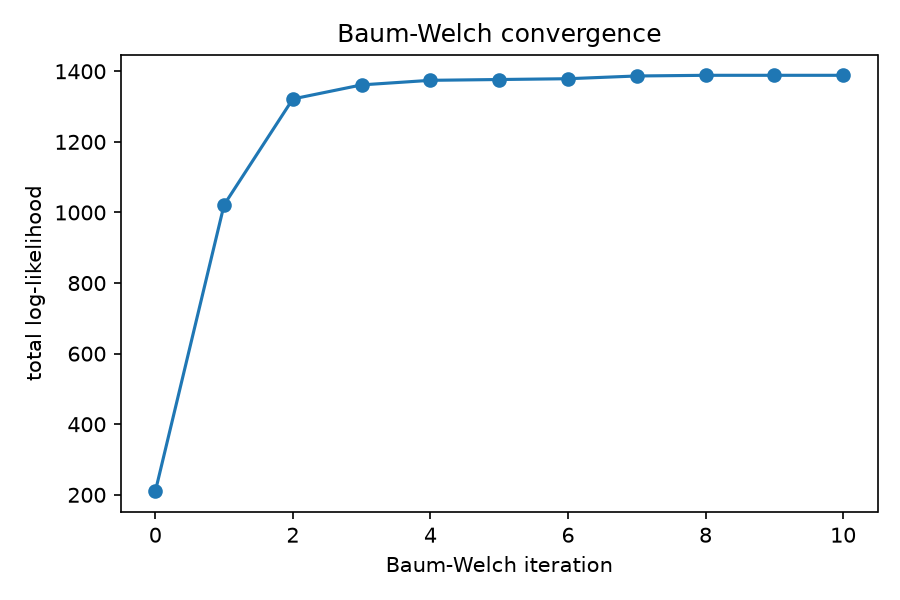

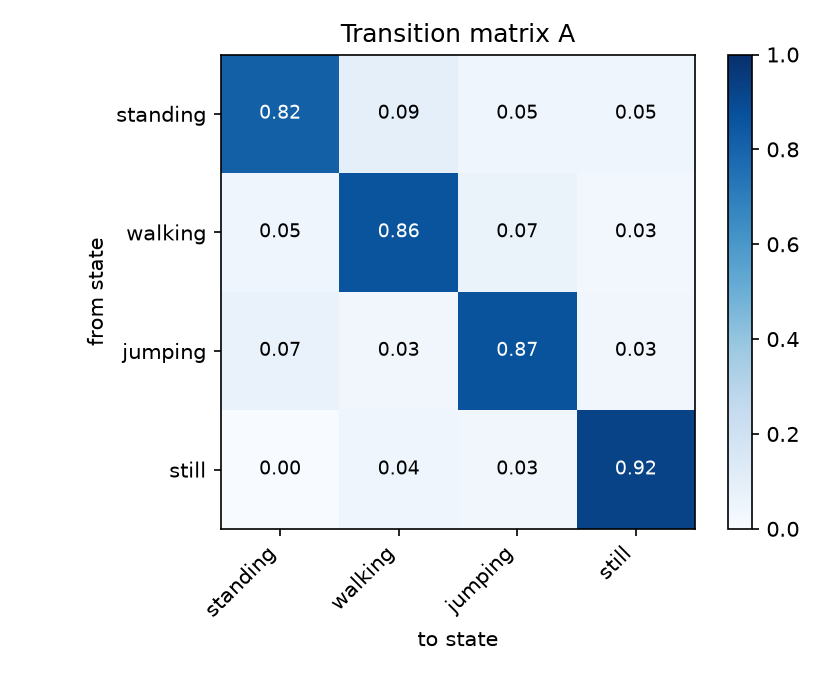

our logL = 1388.5710   hmmlearn logL = 1388.5710   |diff| = 0.00e+00
Viterbi path agreement = 100.00%


In [7]:
hm.save_plots(history, model, STATES, 'plots')
display(Image('plots/bw_convergence.png'))
display(Image('plots/transition_matrix.png'))

v = hm.validate_against_hmmlearn(model, seqs)
print(f"our logL = {v['our_ll']:.4f}   hmmlearn logL = {v['ref_ll']:.4f}   |diff| = {v['ll_diff']:.2e}")
print(f"Viterbi path agreement = {v['path_agreement']*100:.2f}%")

## 5. Evaluation on unseen data

The two held-out mixed sessions are decoded with Viterbi. We report both the
supervised-init model and the Baum-Welch-refined model. Metrics use *pure* windows (those
lying wholly within one activity); boundary windows straddling a transition are excluded
because their true label is ambiguous. Per-activity sensitivity, specificity and accuracy
are computed one-vs-rest from the confusion matrix. The decoded-sequence timeline below
plots the true vs. predicted activity over time for each test session.

In [8]:
sup = hm.GaussianHMM(K, D); sup.fit_supervised(seqs, labs)
print('supervised-init model:')
ev.report('supervised', sup, test_F, STATES)
print('\nbaum-welch-refined model:')
cm, all_acc, pure_acc, rows, overall = ev.report('baum-welch', model, test_F, STATES)

supervised-init model:

supervised
  mixed_100hz_01.csv: overall window accuracy = 0.625
  mixed_50hz_01.csv: overall window accuracy = 0.688
  Overall accuracy - all windows : 0.656
  Overall accuracy - pure windows: 0.712

  Per-activity metrics (pure windows), overall acc = 0.712
  activity      n    sens    spec     acc
  standing     14   1.000   0.605   0.712
  walking      12   0.000   1.000   0.769
  jumping      14   1.000   1.000   1.000
  still        12   0.750   1.000   0.942

baum-welch-refined model:

baum-welch
  mixed_100hz_01.csv: overall window accuracy = 0.875
  mixed_50hz_01.csv: overall window accuracy = 0.906
  Overall accuracy - all windows : 0.891
  Overall accuracy - pure windows: 0.962

  Per-activity metrics (pure windows), overall acc = 0.962
  activity      n    sens    spec     acc
  standing     14   0.929   1.000   0.981
  walking      12   1.000   0.975   0.981
  jumping      14   1.000   0.974   0.981
  still        12   0.917   1.000   0.981


In [9]:
metrics = pd.DataFrame(rows, columns=['n_samples', 'sensitivity', 'specificity', 'accuracy'],
                       index=STATES).round(3)
metrics.loc['OVERALL'] = ['', '', '', round(overall, 3)]
metrics

,n_samples,sensitivity,specificity,accuracy
standing,14,0.929,1.0,0.981
walking,12,1.0,0.975,0.981
jumping,14,1.0,0.974,0.981
still,12,0.917,1.0,0.981
OVERALL,,,,0.962


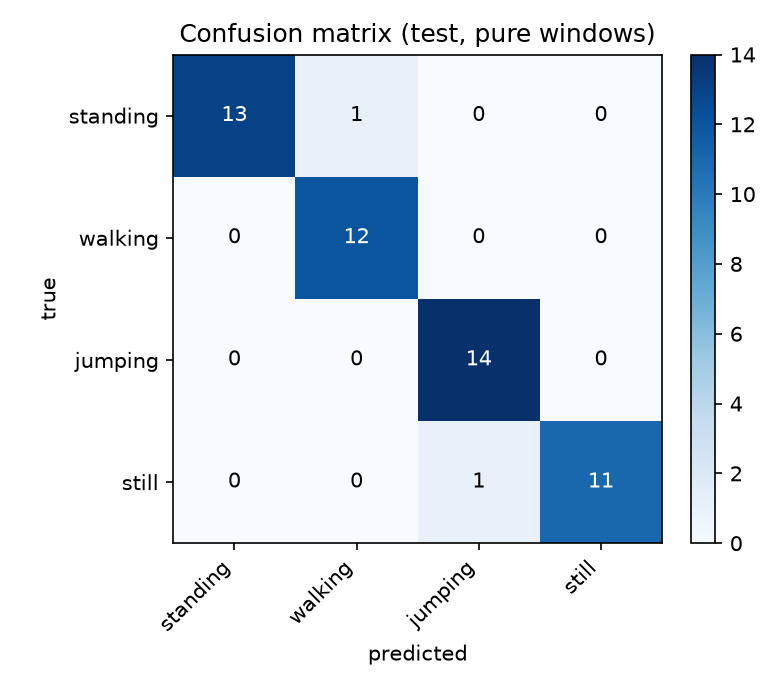

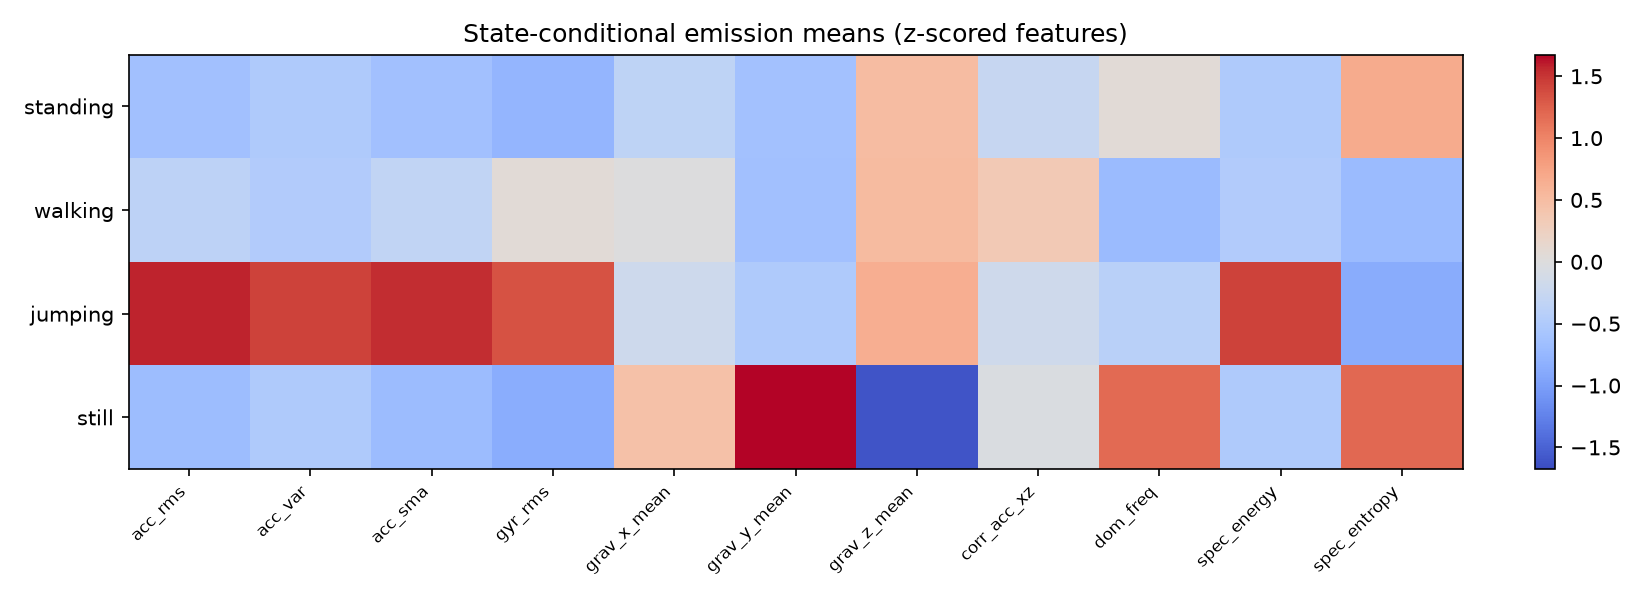

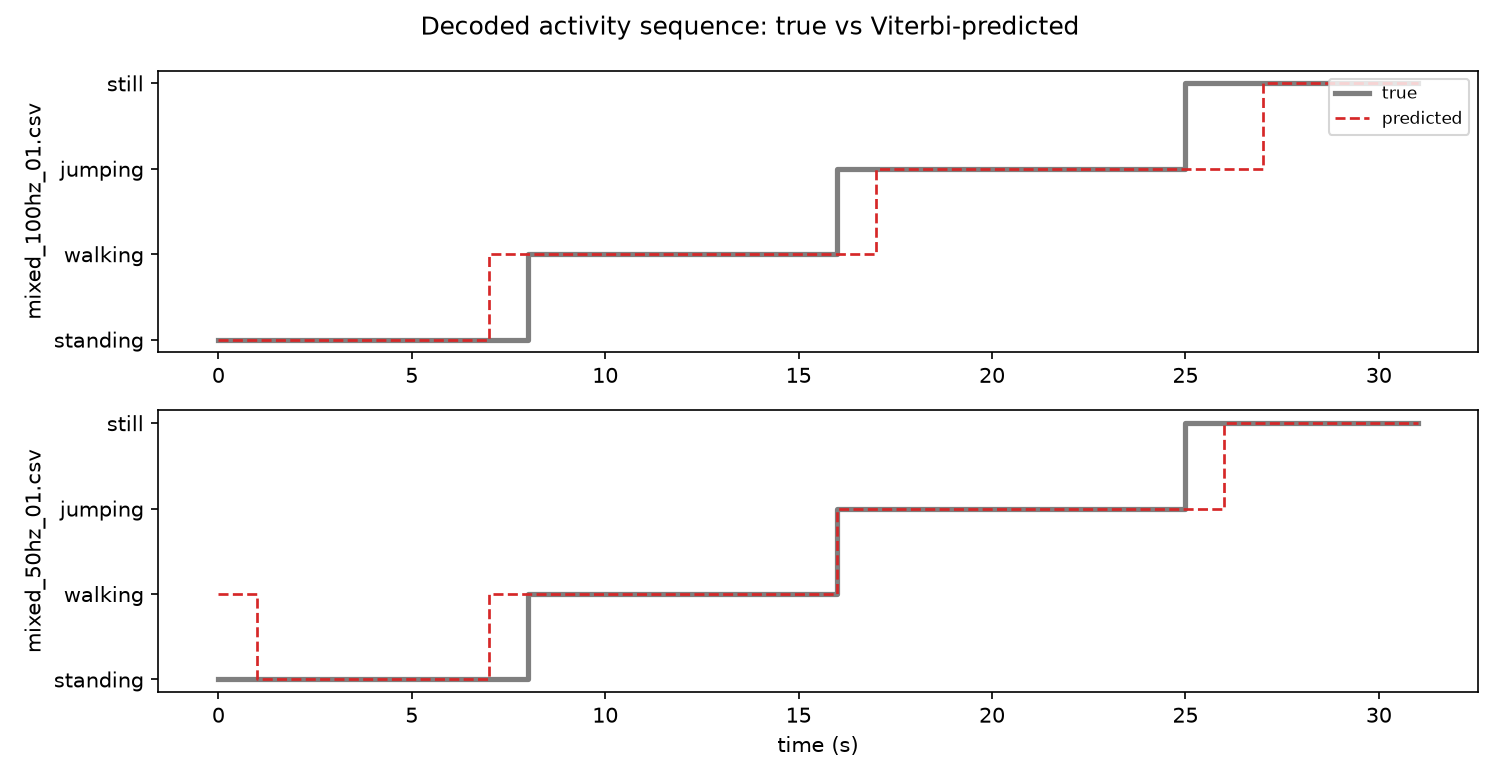

In [10]:
ev.save_confusion(cm, STATES, 'plots/confusion_matrix.png')
ev.save_emissions(model, STATES, FEATURES, 'plots/emission_means.png')
ev.save_decoded_timeline(model, test_F, STATES, 'plots/decoded_timeline.png', hop_seconds=pp.HOP/FS)
display(Image('plots/confusion_matrix.png'))
display(Image('plots/emission_means.png'))
display(Image('plots/decoded_timeline.png'))

## 6. Discussion and conclusion

**Easiest vs hardest to distinguish.** Jumping and still are the easiest: jumping produces
large periodic acceleration spikes (high energy, clear dominant frequency) and still is a
near-flat signal with gravity fully on one axis. The hardest pair is standing vs walking,
which share the same device orientation (gravity on the same axis) and differ only in
motion energy; the supervised model in fact collapsed the two into a single block (walking
sensitivity 0), while Baum-Welch separated them.

**Supervised vs Baum-Welch.** The supervised model had higher *training* accuracy but
Baum-Welch generalised far better on the test set (96% vs 71% pure-window accuracy). The
supervised transition matrix was so persistence-heavy that Viterbi rarely switched into
walking; Baum-Welch's likelihood-driven refinement rebalanced the transitions and
emissions. This illustrates that likelihood and classification accuracy are distinct
objectives, and that the higher-likelihood model won where it mattered.

**Transition probabilities.** The learned matrix is strongly diagonal, which correctly
reflects that activities persist for many windows; off-diagonal mass is small and captures
the rare genuine transitions.

**Sensor noise and sampling rate.** Standing carried more energy than still because of
hand micro-movements while holding the phone, slightly blurring it toward walking.
Harmonising the ~50 Hz and ~100 Hz recordings onto a common 50 Hz grid worked: the model
decoded the 100 Hz test session nearly as well as the 50 Hz one, evidence that windowing
in physical time removed the rate dependence.

**Improvements.** Logging exact activity boundaries during the mixed sessions (rather than
approximating equal segments), adding more participants and sensor placements, richer
per-axis and jerk features, and a duration-aware model (hidden semi-Markov) would improve
boundary precision and robustness.

**Conclusion.** A from-scratch Gaussian HMM, validated against `hmmlearn`, recognises four
activities from smartphone inertial data at ~96% accuracy on unseen recordings, with
robust cross-rate generalisation.